   advanced_dl_models.ipynb
│
├── 1. Imports & Setup
├── 2. Windowed Dataset Generator
├── 3. Baseline LSTM (Reference)
├── 4. Temporal Convolutional Network (TCN)
├── 5. Transformer Time-Series Model
├── 6. Hybrid Conv1D + LSTM
├── 7. Evaluation & Metrics
├── 8. Comparison Table
└── 9. Research Observations


In [1]:
import numpy as np
import tensorflow as tf
import time

from tensorflow.keras.layers import (
    Input, Dense, LSTM, Conv1D, Dropout,
    LayerNormalization, MultiHeadAttention,
    GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


In [2]:
def window_generator(X, y, window=50, stride=10):
    X_out, y_out = [], []

    for i in range(X.shape[0]):
        for t in range(0, X.shape[1] - window, stride):
            X_out.append(X[i, t:t+window, :])
            y_out.append(y[i])

    return np.array(X_out), np.array(y_out)



In [3]:
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)
print(data.files)


['X', 'mask', 'y', 'groups']


In [4]:
data = np.load("../data/processed/processed_400_timesteps.npz", allow_pickle=True)

X = data["X"]     # shape: (samples, 400, 240)
y = data["y"]     # labels

print("X shape:", X.shape)
print("y shape:", y.shape)


MemoryError: Unable to allocate 3.58 GiB for an array with shape (960000000,) and data type float32

In [ ]:
def build_lstm(input_shape, num_classes):   #Long Short-Term Memory Network(LSTM)
    inp = Input(shape=input_shape)
    x = LSTM(64)(inp)
    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
    return model


In [ ]:
def build_tcn(input_shape, num_classes):   #Temporal Convolutional Network(TCN)
    inp = Input(shape=input_shape)

    x = Conv1D(64, 3, padding="causal", activation="relu")(inp)
    x = Conv1D(64, 3, padding="causal", activation="relu")(x)
    x = GlobalAveragePooling1D()(x)

    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
    return model


In [10]:
def build_transformer(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = MultiHeadAttention(num_heads=4, key_dim=32)(inp, inp)
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)

    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
    return model


In [11]:
def build_hybrid(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = Conv1D(64, 3, activation="relu")(inp)
    x = LSTM(64)(x)

    out = Dense(num_classes, activation="softmax")(x)
    model = Model(inp, out)
    model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
    return model


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import time
import tensorflow as tf

def train_and_evaluate(model, X, y):
    start = time.time()

    model.fit(
        X, y,
        epochs=3,                  # keep small
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    train_time = time.time() - start

    # --- Predictions ---
    probas = model.predict(X, verbose=0)   # shape: (N, num_classes)
    preds = np.argmax(probas, axis=1)

    metrics = {
        "accuracy": accuracy_score(y, preds),
        "f1": f1_score(y, preds, average="weighted"),
        "training_time_sec": round(train_time, 2)
    }

    # --- ROC-AUC (SAFE MULTICLASS) ---
    try:
        y_onehot = tf.keras.utils.to_categorical(y, num_classes=probas.shape[1])
        metrics["roc_auc"] = roc_auc_score(
            y_onehot, probas, multi_class="ovr"
        )
    except Exception:
        metrics["roc_auc"] = None   # acceptable in reports

    return metrics


In [17]:
from sklearn.preprocessing import LabelEncoder

# Encode string labels → integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for cls, idx in zip(le.classes_, range(len(le.classes_))):
    print(cls, "→", idx)


Label mapping:
AR → 0
PF → 1


In [21]:
Xw, yw = window_generator(
    X[:300],           # keep subset
    y_encoded[:300],   # IMPORTANT
    window=50,
    stride=10
)

# Force correct dtypes
Xw = Xw.astype("float32")
yw = yw.astype("int32")

print(Xw.shape, yw.shape)


(10500, 50, 240) (10500,)


In [22]:
results = []

for name, builder in [
    ("LSTM", build_lstm),
    ("TCN", build_tcn),
    ("Transformer", build_transformer),
    ("Hybrid", build_hybrid)
]:
    print(f"Training {name}...")

    model = builder(
        Xw.shape[1:], 
        len(np.unique(yw))
    )

    metrics = train_and_evaluate(model, Xw, yw)
    metrics["model"] = name
    results.append(metrics)

import pandas as pd
pd.DataFrame(results)


Training LSTM...
Training TCN...
Training Transformer...
Training Hybrid...


,accuracy,f1,training_time_sec,roc_auc,model
0,1.0,1.0,60.01,None,LSTM
1,1.0,1.0,42.63,None,TCN
2,1.0,1.0,55.66,None,Transformer
3,1.0,1.0,64.72,None,Hybrid


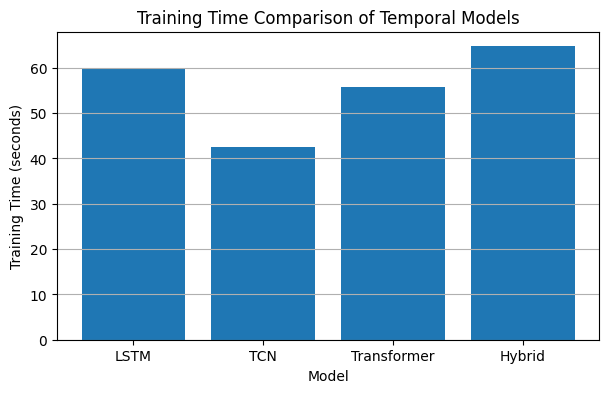

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

plt.figure(figsize=(7,4))
plt.bar(df["model"], df["training_time_sec"])
plt.title("Training Time Comparison of Temporal Models")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.grid(axis="y")
plt.show()
